# Refund intent detection

**Recipe 02** · Level 1 (Beginner) · Decision type: `Noul`

Judge whether a customer message explicitly requests a refund so Python can flag it for the appropriate workflow.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)

## What you will build

A small refund-intent flag for customer messages. Jev reads one message and answers a single yes/no statement: does this message explicitly ask for a refund? A `Noul` answer is a probability, not a label with its own `confidence` field, but a Noul's own certainty is still defined ([S03](https://docs.typesafe.ai/confidence)): how far that probability sits from an even split. Python uses two things chosen on `validation` and then frozen: a business threshold on the probability itself (is this likely a refund request at all?) and a certainty threshold on that same distance-from-even-split (is the message clear enough to act on without a person?). A message that is clear enough and over the business threshold is flagged and queued for the refund workflow; one that is clear enough and under it needs no action; one that is not clear enough goes to the same queue for a different reason: a person, not the threshold, should decide. By the end you will have looked at individual typed answers, including one the threshold gets wrong on purpose and one genuinely ambiguous enough that the certainty gate reroutes it, seen the simulated queue Python builds from the rule, and run an evaluation that reports precision and recall across a sweep of thresholds alongside the real coverage, accuracy and risk the frozen rule buys.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 48 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definition and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    evaluate_selective,
    evaluate_threshold,
    noul_confidence,
    select_confidence_threshold,
    select_threshold,
    threshold_sweep,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.simulation import ReviewQueue
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_threshold_sweep,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number, in text or in a figure.
selection = " (a selection step, not a reported result)"

# Every one of the 48 examples in fixtures/ needs at most one request. This cache makes sure a
# message that is shown individually and later scored in its split is decided once, so the
# whole notebook makes exactly 48 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "refund_requested"
        ]
    return answered[example.id]


run_header(
    2,
    "Refund intent detection",
    backend=backend,
    n_examples=len(scored),
)

Recipe 02: Refund intent detection
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 46 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `ticket_id` and the message `text`. `build_state` passes on the text only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model and every result still traces back to its ticket.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-explicit"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "ticket_id": "RF3001",
  "text": "The shoes I ordered arrived two sizes too small. I'd like a refund, please."
}
Jev sees:
{
  "text": "The shoes I ordered arrived two sizes too small. I'd like a refund, please."
}


## The questions

There is one proposition, and it asks one thing: does this message explicitly ask for a refund? `Noul` fits because the proposition is either true or false of a given message ([S02](https://docs.typesafe.ai/primitives)). It is written as a statement (`helpers.STATEMENT`), not a question, because CONTRIBUTING.md holds `Noul` propositions to a stricter form than TypeSafe's own documentation shows. "Explicitly" carries the weight of this recipe's hard cases: a plain complaint, a question about refund policy, a request for a replacement or store credit, and a refund mentioned only in passing (a past order, a hypothetical, a future possibility) are all close to this statement without making it true, and the two outcome descriptions below spell that out so the model has something to go on besides the single word "refund".

A `Noul` answer is a single probability, the probability that the statement is true, and nothing else: unlike a `Choice` or a `Score` answer, it has no separate `confidence` field in the API response ([S02](https://docs.typesafe.ai/primitives)). That does not mean a Noul has no certainty, though: the confidence page ([S03](https://docs.typesafe.ai/confidence)) gives the reading directly, as the distance between the probability and an even split, `|2p - 1|` -- the same formula a `Choice` between exactly two options would use, just applied to the one probability a Noul already reports. `jev_cookbook.evaluation.noul_confidence` computes this certainty, so "Python's part" below has a second, independent lever beyond the business threshold: not *where* the probability leans, but *how far* it leans from an even split.

In [3]:
proposition = questions["refund_requested"]
print(proposition.instructions)
for name, description in proposition.criteria.items():
    print(f"{name}: {description}")

This message explicitly asks for a refund for the customer's current order.
true: The message asks, right now, for money back on a purchase: using the word refund, or an unmistakable equivalent such as 'give me my money back'. The request can be calm, angry, buried in a longer message, or as short as 'Refund now.'; it is still explicit if a reasonable reader has no doubt the customer wants their money back for this order, even if the ask is hedged ('if that's possible').
false: The message does not currently ask for money back on this order. This covers a plain complaint with no request attached, a question about refund policy in general, a request for a replacement or store credit instead of a refund, a refund mentioned only in passing (a past order, a hypothetical, a future possibility), and a request to cancel a subscription or return an item without saying the word refund or its equivalent.


## One answer up close

Before any aggregate number, look at four typed answers: a clear refund request, a message that only asks about refund policy, one where the stored answer and the gold label disagree, and one that is genuinely ambiguous. Each answer holds just the probability that the statement is true and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

Noul: 0.94 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


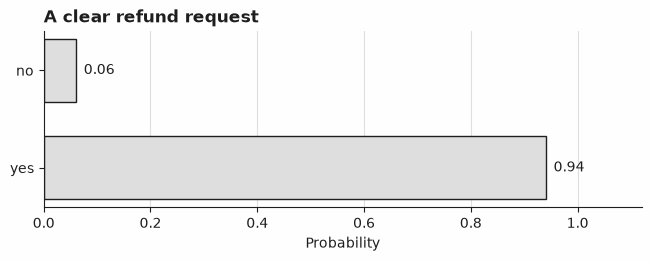

In [4]:
explicit_example = demo["d01-explicit"]
explicit_answer = decide(explicit_example)
show_answer(explicit_answer)
plot_answer_probabilities(explicit_answer, title="A clear refund request")

The shoe-sizing message states outright that the customer wants a refund. The stored answer puts the probability of yes at 0.94, as far from an even split as a probability gets, so both the business threshold and the certainty gate below will treat it the same way: flagged, with nothing for a person to double-check.

In [5]:
policy_example = demo["d02-policy"]
policy_answer = decide(policy_example)
show_answer(policy_answer)

Noul: 0.25 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


"What's your refund policy if this doesn't work out for me?" asks about the policy, not for a refund on an order the customer has already placed; the gold label for this message is false. The stored probability, 0.25, is low but not negligible, because the word "refund" is still there and a policy question is exactly the near miss this proposition is written to exclude.

In [6]:
hard_example = next(e for e in examples if e.id == "v19-hard-wrong")
hard_answer = decide(hard_example)
print(hard_example.fields["text"])
show_answer(hard_answer)

I thought about asking for a refund, but honestly I'd rather just keep it and have it repaired.
Noul: 0.87 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


"I thought about asking for a refund, but honestly I'd rather just keep it and have it repaired" raises a refund only to set it aside; this recipe's gold label is false. The stored answer calls it confidently true, far enough from an even split that no certainty gate could tell this apart from a genuinely confident, correct answer -- certainty measures how far a probability leans, not whether it leans the right way. The evaluation below counts this one as wrong, on purpose: a fixture set where every stored answer is right would not teach anything about where this recipe's rule can be fooled. Nothing here says *why* a real model would get this one wrong, because nothing here is a real model: the probability was written by hand for this fixture, not produced by Jev.

In [7]:
ambiguous_example = next(e for e in examples if e.id == "v22-borderline")
ambiguous_answer = decide(ambiguous_example)
print(ambiguous_example.fields["text"])
show_answer(ambiguous_answer)

I'm fed up with this item breaking constantly, what are my options here?
Noul: 0.52 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


"I'm fed up with this item breaking constantly, what are my options here?" could go either way: frustration this strong often does lead to a refund request, but this message has not made one yet. The stored probability, 0.52, is barely on the "true" side of an even split -- and the gold label here is false. This is one of four messages in this recipe's fixtures held deliberately within 0.06 of an even split, with gold labels split both ways (two true, two false), so that a message's probability alone does not reliably say which way it should go. "Python's part" below is where a message this close to 0.5 stops being decided by the business threshold at all.

## Python's part

Jev supplies the probability; what happens with it is code. `route` in `helpers.py` decides one of three outcomes for a message, and CONTRIBUTING.md section 4 requires the third: "Uncertain or inconsistent results go to an explicit review outcome." A message whose certainty (`noul_confidence`, "The questions" above) does not clear `min_confidence` goes to `REVIEW`, whichever way its probability leans -- the mid-range TypeSafe's own Noul documentation routes to a person. Only once a message clears that gate does the business `threshold` decide `FLAGGED` or `NOT_FLAGGED`. `tests/test_helpers.py` checks both boundaries, both gates' valid ranges, and that a confidently wrong message (`v19-hard-wrong`, shown above) still reaches `FLAGGED` rather than being quietly excused into `REVIEW`.

Both thresholds are chosen here, on `validation`, and then frozen for the rest of this notebook. `select_threshold` sweeps every observed probability as a candidate business cut-off and picks the one with the highest `f1` (the harmonic mean of precision and recall, explained below). `select_confidence_threshold` then sweeps every observed certainty value and picks the lowest one whose answered messages cover at least 70% of `validation` without excluding any more accuracy than it has to -- a business choice (review at most 30% of messages) stated as `min_coverage=0.7`, not a property of the data. Applying both, frozen, to the four answers shown above shows all three outcomes the rule can produce.

In [8]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_noul = [a.noul for a in val_answers]
threshold = select_threshold(val_gold, val_noul, objective="f1")
print(f"business threshold, frozen from here on: {threshold:.2f}{selection}")

# The certainty gate is chosen from the business decision alone (`would_flag`, ignoring any
# review), the same way recipe 01 chooses its confidence threshold from the raw Choice: what
# would route() decide with no gate at all, and was that decision right?
would_flag = [n >= threshold for n in val_noul]
raw_correct = [f == g for f, g in zip(would_flag, val_gold, strict=True)]
val_certainty = noul_confidence(val_noul)
min_confidence = select_confidence_threshold(raw_correct, val_certainty, min_coverage=0.7)
print(f"certainty threshold, frozen from here on: {min_confidence:.2f}{selection}")

for shown_example, shown_answer in (
    (explicit_example, explicit_answer),
    (policy_example, policy_answer),
    (hard_example, hard_answer),
    (ambiguous_example, ambiguous_answer),
):
    result = helpers.route(
        shown_example.fields["ticket_id"], shown_answer, threshold, min_confidence
    )
    print(f"{result.ticket_id}: noul {shown_answer.noul:.2f} -> {result.outcome} ({result.reason})")

business threshold, frozen from here on: 0.48 (a selection step, not a reported result)
certainty threshold, frozen from here on: 0.55 (a selection step, not a reported result)
RF3001: noul 0.94 -> flagged (noul at or above the threshold: queued for the refund workflow)
RF3002: noul 0.25 -> not_flagged (noul below the threshold: no refund action needed)
RF1019: noul 0.87 -> flagged (noul at or above the threshold: queued for the refund workflow)
RF1022: noul 0.52 -> review (too close to an even split to trust either way: needs a person)


Issue #2 asks for more than a printed decision: a flagged message is supposed to land in a simulated workflow queue. `jev_cookbook.simulation.ReviewQueue` is the shared primitive for exactly this (`docs/simulation.md`): `submit` records an item, the reason it was sent, and the typed answer behind that reason, and nothing in it executes anything. Both `FLAGGED` and `REVIEW` outcomes belong there -- one because a person needs to process a likely refund, the other because a person needs to decide what the message even is -- and `NOT_FLAGGED` messages never touch the queue at all. This cell builds the one queue the rest of this notebook uses, from the four examples routed just above: the ambiguous one is the case where the certainty gate actually fires here, for a different reason than the confidently wrong one above it.

In [9]:
queue = ReviewQueue()
for example, answer_ in (
    (explicit_example, explicit_answer),
    (policy_example, policy_answer),
    (hard_example, hard_answer),
    (ambiguous_example, ambiguous_answer),
):
    result = helpers.route(example.fields["ticket_id"], answer_, threshold, min_confidence)
    if result.outcome != helpers.NOT_FLAGGED:
        queue.submit({"ticket_id": result.ticket_id}, result.reason, answer=answer_)
print(f"{len(queue)} items queued so far{selection}")
for item in queue.to_dicts():
    print(item["item"], "--", item["reason"])

3 items queued so far (a selection step, not a reported result)
{'ticket_id': 'RF3001'} -- noul at or above the threshold: queued for the refund workflow
{'ticket_id': 'RF1019'} -- noul at or above the threshold: queued for the refund workflow
{'ticket_id': 'RF1022'} -- too close to an even split to trust either way: needs a person


## Evaluation

Both thresholds were chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.route` is applied to every example in `validation` and in `test`, and the counts below come from what it actually returns, not from a separate reimplementation of the same conditions -- including the selective-prediction numbers further down, which read `route`'s own `would_flag` field rather than re-checking `noul >= threshold`. Alongside that, `jev_cookbook.evaluation` reports precision and recall across the full threshold sweep and the coverage, accuracy and risk the certainty gate actually buys. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number and figure, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [10]:
def report(chosen, decided, gold, threshold, min_confidence):
    """Apply route to every answer and tally what it actually did."""
    results = [
        helpers.route(e.fields["ticket_id"], a, threshold, min_confidence)
        for e, a in zip(chosen, decided, strict=True)
    ]
    counts = {helpers.FLAGGED: 0, helpers.REVIEW: 0, helpers.NOT_FLAGGED: 0}
    right_flagged = 0
    for r, g in zip(results, gold, strict=True):
        counts[r.outcome] += 1
        if r.outcome == helpers.FLAGGED and g:
            right_flagged += 1
    return results, counts, right_flagged


val_results, val_counts, val_right_flagged = report(
    val_examples, val_answers, val_gold, threshold, min_confidence
)
print(f"validation, {len(val_examples)} examples{selection}")
print(f"flagged for refund review: {val_counts[helpers.FLAGGED]}{selection}")
print(
    f"  right among those flagged: {val_right_flagged} of {val_counts[helpers.FLAGGED]}{selection}"
)
print(f"sent to review (too uncertain): {val_counts[helpers.REVIEW]}{selection}")
print(f"not flagged, no action: {val_counts[helpers.NOT_FLAGGED]}{selection}")

validation, 23 examples (a selection step, not a reported result)
flagged for refund review: 10 (a selection step, not a reported result)
  right among those flagged: 9 of 10 (a selection step, not a reported result)
sent to review (too uncertain): 2 (a selection step, not a reported result)
not flagged, no action: 11 (a selection step, not a reported result)


`precision` is the fraction of flagged messages that were actually refund requests, and `recall` is the fraction of the real refund requests in this split the rule found at all; `f1` is their harmonic mean, a single number that is low whenever either one is. These are computed on the business decision alone, before the certainty gate removes anything. The chart below sweeps every threshold `select_threshold` considered on `validation` -- and it carries the `selection` label too, in every run mode, because a figure drawn from `validation` is exactly as much a selection step as a printed number.

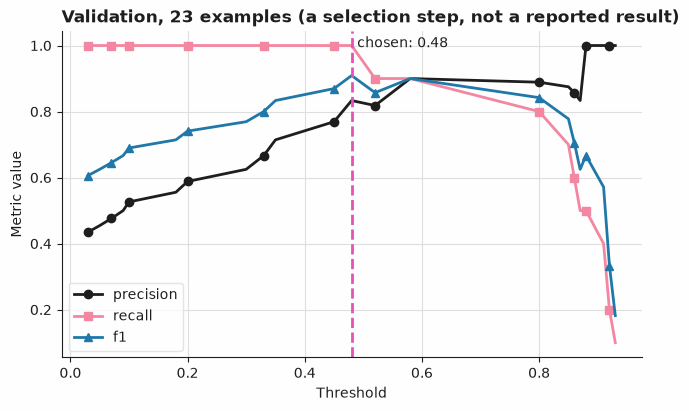

In [11]:
sweep = threshold_sweep(val_gold, val_noul)
plot_threshold_sweep(
    sweep, chosen=threshold, title=f"Validation, {len(val_examples)} examples{selection}"
)

`test` is used once, after both thresholds are frozen. `evaluate_threshold` reports the same precision, recall and `f1` at exactly the business threshold on `test`, ignoring the certainty gate entirely -- these numbers describe what the threshold alone would do if nothing were ever reviewed. `evaluate_selective` then reports what the certainty gate actually buys, using `would_flag` (from `route`, never recomputed) as the fixed decision and `noul_confidence` as the independent signal that gates it: `coverage` is the fraction of `test` messages the gate lets through without review; `accuracy` is the fraction of those whose business decision matched the gold label; and `risk` is its complement, `1 - accuracy`, the fraction of ungated decisions that turn out wrong. Because a decision Python acts on without a person goes straight into a real queue or gets no action at all, `risk` is the number that matters to whoever relies on that.

In [12]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]
test_noul = [a.noul for a in test_answers]

test_results, test_counts, test_right_flagged = report(
    test_examples, test_answers, test_gold, threshold, min_confidence
)
point = evaluate_threshold(test_gold, test_noul, threshold)
print(f"test, {len(test_examples)} examples, both thresholds frozen{check}")
print(f"flagged for refund review: {test_counts[helpers.FLAGGED]}{check}")
print(f"  right among those flagged: {test_right_flagged} of {test_counts[helpers.FLAGGED]}{check}")
print(f"sent to review (too uncertain): {test_counts[helpers.REVIEW]}{check}")
print(f"not flagged, no action: {test_counts[helpers.NOT_FLAGGED]}{check}")
print(f"precision {point.precision:.3f}  recall {point.recall:.3f}  f1 {point.f1:.3f}{check}")

# would_flag comes from route()'s own output -- the business decision it already made -- never
# recomputed here as `noul >= threshold`.
test_would_flag = [r.would_flag for r in test_results]
test_correct = [f == g for f, g in zip(test_would_flag, test_gold, strict=True)]
test_certainty = noul_confidence(test_noul)
selective = evaluate_selective(test_correct, test_certainty, min_confidence)
print(
    f"coverage {selective.coverage:.3f} "
    f"(ungated {selective.n_answered} of {selective.n_total}){check}"
)
print(f"accuracy among ungated decisions {selective.accuracy:.3f}{check}")
print(f"risk among ungated decisions {selective.risk:.3f}{check}")

test, 23 examples, both thresholds frozen (a pipeline check, not a Jev result)
flagged for refund review: 10 (a pipeline check, not a Jev result)
  right among those flagged: 9 of 10 (a pipeline check, not a Jev result)
sent to review (too uncertain): 2 (a pipeline check, not a Jev result)
not flagged, no action: 11 (a pipeline check, not a Jev result)
precision 0.833  recall 1.000  f1 0.909 (a pipeline check, not a Jev result)
coverage 0.913 (ungated 21 of 23) (a pipeline check, not a Jev result)
accuracy among ungated decisions 0.952 (a pipeline check, not a Jev result)
risk among ungated decisions 0.048 (a pipeline check, not a Jev result)


The one message `test` gets wrong among the flagged is `t19-hard-wrong` -- far enough from an even split that the certainty gate lets it straight through, and above the business threshold, so it is queued even though the gold label is false. That one error is the risk figure above. The rule sends two messages to review instead of deciding automatically: `t21-borderline`, a hedged true request, and `t22-borderline`, a vague complaint that is actually false; both sit close enough to an even split that the certainty gate cannot tell which one is the real risk, so both go to a person and neither counts against `risk` or against `precision`/`recall` either way -- `route`'s outcome does not change what the raw business decision *would* have been, it only changes whether Python acts on it alone. Neither frozen number is a guarantee about anything but this fixture set: a threshold and a certainty gate chosen on `validation` are a trade-off measured there, not a promise about `test` or about any message this recipe has not seen -- which is why `validation`'s own flagged-but-wrong count is reported above too, rather than only the clean parts of this story.

The same queue from "Python's part" now gets every `validation` and `test` message `route` sent to `FLAGGED` or `REVIEW`, so it reflects the whole run rather than the four examples shown up close.

In [13]:
already_queued = {hard_example.id, ambiguous_example.id}  # routed, and some queued, just above
for example, answer_, result in zip(
    val_examples + test_examples,
    val_answers + test_answers,
    val_results + test_results,
    strict=True,
):
    if result.outcome != helpers.NOT_FLAGGED and example.id not in already_queued:
        queue.submit({"ticket_id": result.ticket_id}, result.reason, answer=answer_)

by_reason = {}
for item in queue.to_dicts():
    by_reason[item["reason"]] = by_reason.get(item["reason"], 0) + 1
print(f"{len(queue)} items in the queue across both scored splits{check}")
for reason, count in sorted(by_reason.items()):
    print(f"  {count} because: {reason}{check}")

25 items in the queue across both scored splits (a pipeline check, not a Jev result)
  21 because: noul at or above the threshold: queued for the refund workflow (a pipeline check, not a Jev result)
  4 because: too close to an even split to trust either way: needs a person (a pipeline check, not a Jev result)


## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule, the queue and the evaluation behave as designed on 46 scored messages (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose (including one wrong *and* far from an even split on each split, to show what the certainty gate does not catch), so every number above describes this fixture set and not a model.

In [14]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard message to `ROWS` in `build_fixtures.py` with the probability you expect a model might give, run `python build_fixtures.py`, and see where `route` sends it, and whether the queue picks it up.
- Change `select_confidence_threshold`'s `min_coverage` and see how many messages go to review instead of being decided outright.
- Neighbouring recipes: [`01-sentiment-classification`](../01-sentiment-classification/) (a `Choice` question with a confidence-based review split) and [`03-response-clarity-scoring`](../03-response-clarity-scoring/) (a `Score` question), the two other decision types `Noul` sits alongside.